In [16]:
# Phase 3 — Graph-Enhanced ETA Prediction Model
# We build two models and compare them:
#Baseline XGBoost— trip-level features only
#Graph-Enhanced XGBoost — trip features + graph knowledge
# End goal: prove the graph model beats baseline on MAE and 15% accuracy

In [17]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
 
from node2vec import Node2Vec
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
 
print("Imports ready")

Imports ready


In [18]:
OUT_DIR = "../data/processed"
VIZ_DIR = "../outputs/phase3_visuals"
os.makedirs(VIZ_DIR, exist_ok=True)
 
G                   = nx.read_graphml(f"{OUT_DIR}/delivery_network.graphml")
node_metrics        = pd.read_csv(f"{OUT_DIR}/node_metrics.csv")
corridor_aggregates = pd.read_csv(f"{OUT_DIR}/corridor_aggregates.csv")
train_df            = pd.read_csv(f"{OUT_DIR}/train_clean.csv",
                                  parse_dates=["od_start_time", "trip_creation_time"])
test_df             = pd.read_csv(f"{OUT_DIR}/test_clean.csv",
                                  parse_dates=["od_start_time", "trip_creation_time"])
 
print("Loaded successfully")
print(f"  Graph               : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  node_metrics        : {node_metrics.shape}")
print(f"  corridor_aggregates : {corridor_aggregates.shape}")
print(f"  train_df            : {train_df.shape}")
print(f"  test_df             : {test_df.shape}")
print(f"  Target range        : {train_df['segment_factor_capped'].min():.2f} to {train_df['segment_factor_capped'].max():.2f}")

Loaded successfully
  Graph               : 1657 nodes, 2783 edges
  node_metrics        : (1657, 18)
  corridor_aggregates : (2783, 12)
  train_df            : (103049, 27)
  test_df             : (39218, 27)
  Target range        : 0.01 to 11.60


In [19]:
#Step 1 — Merge Hub Features onto Every Trip Row
# Every trip has a source_center and destination_center.
# We attach the graph metrics of both hubs to every trip row.
# This is how graph knowledge enters the model.

In [20]:
import xgboost as xgb

# 1. Check if XGBoost was built with GPU support
try:
    xgb.XGBRegressor(device='cuda').fit(np.zeros((1,1)), np.zeros(1))
    print("XGBoost GPU support: YES")
except Exception as e:
    print(f"XGBoost GPU support: NO (Error: {e})")

# 2. In your model definition, ensure you use:
# model = XGBRegressor(device='cuda', tree_method='hist')


XGBoost GPU support: YES


In [21]:
#nwo that there are source and dest and we have to attach the metrices to each node adn edge , we select 
#only those metrices that matter as model features 

hub_feats = node_metrics[[
    "hub_id",
    "betweenness_centrality",
    "bottleneck_score",
    "avg_outgoing_sla_breach",
    "avg_outgoing_factor",
    "in_degree",
    "out_degree"
]].copy()
 
print(f"Hub features table: {hub_feats.shape}")
print(f"Columns: {hub_feats.columns.tolist()}")
hub_feats.head()

Hub features table: (1657, 7)
Columns: ['hub_id', 'betweenness_centrality', 'bottleneck_score', 'avg_outgoing_sla_breach', 'avg_outgoing_factor', 'in_degree', 'out_degree']


,hub_id,betweenness_centrality,bottleneck_score,avg_outgoing_sla_breach,avg_outgoing_factor,in_degree,out_degree
0,IND000000ACB,0.343811,0.733007,0.794141,1.599466,45,49
1,IND562132AAA,0.237455,0.575673,0.774111,1.543819,36,35
2,IND743270AAA,0.001639,0.504730,1.000000,11.600000,1,1
3,IND482002AAA,0.000000,0.503061,1.000000,11.600000,1,1
4,IND741201AAC,0.000000,0.503061,1.000000,11.600000,1,1


In [23]:
# ============================================================
# Merge Graph/Hub Features into Train & Test DataFrames
# ============================================================

def merge_hub_features(df, hub_feats):
    """
    Adds source and destination hub-level graph features
    into the shipment dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Main shipment/order dataframe
        
    hub_feats : pd.DataFrame
        Hub-level graph features dataframe
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with merged source & destination features
    """

    # --------------------------------------------------------
    # Merge SOURCE hub features
    # --------------------------------------------------------
    df = df.merge(
        hub_feats.rename(columns={
            "hub_id"                  : "source_center",
            "betweenness_centrality"  : "src_betweenness",
            "bottleneck_score"        : "src_bottleneck_score",
            "avg_outgoing_sla_breach" : "src_sla_breach",
            "avg_outgoing_factor"     : "src_avg_factor",
            "in_degree"               : "src_in_degree",
            "out_degree"              : "src_out_degree",
        }),
        on="source_center",
        how="left"
    )

    # --------------------------------------------------------
    # Merge DESTINATION hub features
    # --------------------------------------------------------
    df = df.merge(
        hub_feats.rename(columns={
            "hub_id"                  : "destination_center",
            "betweenness_centrality"  : "dst_betweenness",
            "bottleneck_score"        : "dst_bottleneck_score",
            "avg_outgoing_sla_breach" : "dst_sla_breach",
            "avg_outgoing_factor"     : "dst_avg_factor",
            "in_degree"               : "dst_in_degree",
            "out_degree"              : "dst_out_degree",
        }),
        on="destination_center",
        how="left"
    )

    return df


# ============================================================
# Apply feature merging
# ============================================================

train_df = merge_hub_features(train_df, hub_feats)
test_df  = merge_hub_features(test_df, hub_feats)


# ============================================================
# Verification
# ============================================================

print("✅ Hub features merged successfully")
print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")


# ============================================================
# Preview merged columns
# ============================================================

sample_cols = [
    "source_center",
    "src_betweenness",
    "src_bottleneck_score",
    "destination_center",
    "dst_betweenness",
    "dst_bottleneck_score"
]

display(train_df[sample_cols].head(3))

✅ Hub features merged successfully
Train Shape : (103049, 39)
Test Shape  : (39218, 39)


,source_center,src_betweenness,src_bottleneck_score,destination_center,dst_betweenness,dst_bottleneck_score
0,IND388121AAA,0.000616,0.20962,IND388620AAB,0.001636,0.248084
1,IND388121AAA,0.000616,0.20962,IND388620AAB,0.001636,0.248084
2,IND388121AAA,0.000616,0.20962,IND388620AAB,0.001636,0.248084


In [24]:
corr_feats = corridor_aggregates[[
    "source_center", "destination_center",
    "median_factor", "sla_breach_rate",
    "p75_factor", "p90_factor",
    "trip_count", "median_distance"
]].rename(columns={
    "median_factor"   : "corr_median_factor",
    "sla_breach_rate" : "corr_sla_breach_rate",
    "p75_factor"      : "corr_p75_factor",
    "p90_factor"      : "corr_p90_factor",
    "trip_count"      : "corr_trip_count",
    "median_distance" : "corr_median_distance",
})
 
train_df = train_df.merge(corr_feats, on=["source_center","destination_center"], how="left")
test_df  = test_df.merge(corr_feats,  on=["source_center","destination_center"], how="left")
 
print("Corridor features merged")
print(f"Train shape now: {train_df.shape}")
 
# Some trips may be on corridors not seen before — fill with median
corr_cols = ["corr_median_factor","corr_sla_breach_rate","corr_p75_factor",
             "corr_p90_factor","corr_trip_count","corr_median_distance"]
for col in corr_cols:
    med = train_df[col].median()
    train_df[col] = train_df[col].fillna(med)
    test_df[col]  = test_df[col].fillna(med)
 
print(f"Missing values after fill: {train_df[corr_cols].isnull().sum().sum()}")

Corridor features merged
Train shape now: (103049, 45)
Missing values after fill: 0


In [25]:
def add_time_features(df):
    df = df.copy()
    df["hour"]        = df["od_start_time"].dt.hour
    df["day_of_week"] = df["od_start_time"].dt.dayofweek
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    return df
 
def encode_categoricals(df):
    df = df.copy()
    le_route = LabelEncoder()
    le_time  = LabelEncoder()
    df["route_type_enc"]  = le_route.fit_transform(df["route_type"].astype(str))
    df["time_bucket_enc"] = le_time.fit_transform(df["time_bucket"].astype(str))
    return df
 
train_df = add_time_features(train_df)
test_df  = add_time_features(test_df)
train_df = encode_categoricals(train_df)
test_df  = encode_categoricals(test_df)
 
print("Time features and encodings added")
print(f"hour range         : {train_df['hour'].min()} - {train_df['hour'].max()}")
print(f"day_of_week range  : {train_df['day_of_week'].min()} - {train_df['day_of_week'].max()}")
print(f"route_type_enc     : {train_df['route_type_enc'].unique()}")
print(f"time_bucket_enc    : {train_df['time_bucket_enc'].unique()}")

Time features and encodings added
hour range         : 0 - 23
day_of_week range  : 0 - 6
route_type_enc     : [0 1]
time_bucket_enc    : [5 1 0 2 3 4]


In [26]:
# Step 2 — node2vec Embeddings
# node2vec learns a 16-dimensional vector for every hub
# based on its position and neighborhood in the graph.
# Hubs with similar network roles get similar vectors.
# These vectors become 32 extra features per trip (source + destination).

In [27]:
#running the n2vec on the made graph 
print("Running node2vec — this takes ~2 minutes...")
print("Parameters:")
print("  dimensions  = 16  (vector size per hub)")
print("  walk_length = 30  (steps per random walk)")
print("  num_walks   = 100 (walks starting from each node)")
print("  window      = 10  (context window for learning)")
 
n2v = Node2Vec(
    G,
    dimensions  = 16,
    walk_length = 30,
    num_walks   = 100,
    weight_key  = "weight",   # use edge delay factor to guide walks
    workers     = 2,
    quiet       = True
)
 
model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
 
print("node2vec complete")
print(f"Embedding for first node: {model_n2v.wv[list(G.nodes())[0]].shape}")

Running node2vec — this takes ~2 minutes...
Parameters:
  dimensions  = 16  (vector size per hub)
  walk_length = 30  (steps per random walk)
  num_walks   = 100 (walks starting from each node)
  window      = 10  (context window for learning)
node2vec complete
Embedding for first node: (16,)


In [28]:
#BUILD AND SAVE EMBEDDINGS FRAME 
nodes      = list(G.nodes())
emb_matrix = np.array([model_n2v.wv[n] for n in nodes])
emb_cols   = [f"n2v_{i}" for i in range(16)]
 
emb_df = pd.DataFrame(emb_matrix, columns=emb_cols)
emb_df["hub_id"] = nodes
 
emb_df.to_csv(f"{OUT_DIR}/node2vec_embeddings.csv", index=False)
 
print(f"Embeddings saved — shape: {emb_df.shape}")
print("Phase 4 will reuse this file directly")
emb_df.head()

Embeddings saved — shape: (1657, 17)
Phase 4 will reuse this file directly


,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,hub_id
0,0.720565,0.259585,2.340590,1.744443,1.282750,-1.076807,1.931351,-0.517275,0.490893,0.944805,-0.855338,-0.545901,1.513992,-2.125063,-0.394488,-0.219797,IND388121AAA
1,0.701986,0.248442,2.356931,1.834830,1.474317,-1.146507,1.995400,-0.466285,0.544683,0.955832,-0.805536,-0.653735,1.379689,-2.010902,-0.308686,-0.253432,IND388620AAB
2,-0.062339,-0.593280,0.792926,1.040339,0.035148,0.336398,0.436132,0.380554,0.035966,0.289579,0.032856,-0.866239,-0.199935,-0.269224,-0.976005,-0.138618,IND421302AAG
3,-0.402093,-0.696956,1.216161,1.960015,-0.014775,0.556023,0.536141,0.561130,-0.172149,0.113444,0.165908,-0.748116,-0.408643,-0.112463,-0.972558,-0.297869,IND400011AAA
4,-0.134222,-1.035278,0.775233,-0.057270,-0.044078,-0.216591,0.420419,-0.443786,0.371325,-0.722283,0.208406,-0.380157,-0.246843,-0.659710,-0.728590,-0.008477,IND562132AAA


In [29]:
#merge embeddings on train and test 
src_emb = emb_df.rename(columns={
    **{f"n2v_{i}": f"src_n2v_{i}" for i in range(16)},
    "hub_id": "source_center"
})
# Destination hub embeddings — prefix dst_n2v_
dst_emb = emb_df.rename(columns={
    **{f"n2v_{i}": f"dst_n2v_{i}" for i in range(16)},
    "hub_id": "destination_center"
})
 
train_df = train_df.merge(src_emb, on="source_center", how="left")
train_df = train_df.merge(dst_emb, on="destination_center", how="left")
test_df  = test_df.merge(src_emb,  on="source_center", how="left")
test_df  = test_df.merge(dst_emb,  on="destination_center", how="left")
 
# Fill any hub not in graph with zeros
n2v_cols = [f"src_n2v_{i}" for i in range(16)] + [f"dst_n2v_{i}" for i in range(16)]
for col in n2v_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)
 
print(f"Embeddings merged — train shape: {train_df.shape}")
print(f"n2v columns added: {len(n2v_cols)}")

Embeddings merged — train shape: (103049, 82)
n2v columns added: 32


In [30]:
train_df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor',
       'time_bucket', 'sla_breach', 'segment_factor_capped', 'src_betweenness',
       'src_bottleneck_score', 'src_sla_breach', 'src_avg_factor',
       'src_in_degree', 'src_out_degree', 'dst_betweenness',
       'dst_bottleneck_score', 'dst_sla_breach', 'dst_avg_factor',
       'dst_in_degree', 'dst_out_degree', 'corr_median_factor',
       'corr_sla_breach_rate', 'corr_p75_factor', 'corr_p90_factor',
       'corr_trip_count', 'corr_median_distance', 'hour', 'day_of_week',
       'is_weekend', 'route_type

In [31]:
#step -3 -> defining the feature sets -> baseline is only what osrm know 
#and graph -> baseline and everything 
#we define some features for model improvement , xgboost fill figure out which ones matter the most 
BASELINE_FEATURES = [
    "segment_osrm_time",       # OSRM prediction
    "segment_osrm_distance",   # distance in km
    "route_type_enc",          # FTL=0, Carting=1
    "time_bucket_enc",         # time of day encoded
    "hour",                    # departure hour
    "day_of_week",             # Monday=0 to Sunday=6
    "is_weekend",              # 1 if Sat or Sun
]
 
GRAPH_FEATURES = BASELINE_FEATURES + [
    # Source hub graph metrics
    "src_betweenness",
    "src_bottleneck_score",
    "src_sla_breach",
    "src_avg_factor",
    "src_in_degree",
    "src_out_degree",
    # Destination hub graph metrics
    "dst_betweenness",
    "dst_bottleneck_score",
    "dst_sla_breach",
    "dst_avg_factor",
    # Corridor historical stats
    "corr_median_factor",
    "corr_sla_breach_rate",
    "corr_p75_factor",
    "corr_p90_factor",
    "corr_trip_count",
    # node2vec embeddings (32 dimensions total)
] + n2v_cols
 
TARGET = "segment_factor_capped"
 
# Build train/test matrices
X_train_base  = train_df[BASELINE_FEATURES]
X_test_base   = test_df[BASELINE_FEATURES]
X_train_graph = train_df[GRAPH_FEATURES]
X_test_graph  = test_df[GRAPH_FEATURES]
y_train       = train_df[TARGET]
y_test        = test_df[TARGET]
 
print("Feature sets defined")
print(f"  Baseline features : {len(BASELINE_FEATURES)}")
print(f"  Graph features    : {len(GRAPH_FEATURES)}")
print(f"  Extra from graph  : {len(GRAPH_FEATURES) - len(BASELINE_FEATURES)}")
print(f"  Train samples     : {len(X_train_base):,}")
print(f"  Test samples      : {len(X_test_base):,}")
print()
print(f"  Target mean  : {y_train.mean():.3f}")
print(f"  Target median: {y_train.median():.3f}")
print(f"  Target std   : {y_train.std():.3f}")

Feature sets defined
  Baseline features : 7
  Graph features    : 54
  Extra from graph  : 47
  Train samples     : 103,049
  Test samples      : 39,218

  Target mean  : 2.094
  Target median: 1.692
  Target std   : 1.551


In [32]:
#step 4 -> training the models and comparision 
#training the baseline xgboost model 
XGB_PARAMS = dict(
    n_estimators        = 500,
    learning_rate       = 0.05,
    max_depth           = 6,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    random_state        = 42,
    n_jobs              = -1,
    early_stopping_rounds = 20,
    eval_metric         = "mae",
)
 
print("Training baseline XGBoost...")
print(f"Features: {len(BASELINE_FEATURES)}")
 
baseline_model = XGBRegressor(**XGB_PARAMS)
baseline_model.fit(
    X_train_base, y_train,
    eval_set   = [(X_test_base, y_test)],
    verbose    = False
)
 
print("Baseline model trained")
print(f"Best iteration: {baseline_model.best_iteration}")

Training baseline XGBoost...
Features: 7
Baseline model trained
Best iteration: 114


In [33]:
#trainign the graph enhanced model with graph features 
print("Training graph-enhanced XGBoost...")
print(f"Features: {len(GRAPH_FEATURES)}")
 
enhanced_model = XGBRegressor(**XGB_PARAMS)
enhanced_model.fit(
    X_train_graph, y_train,
    eval_set   = [(X_test_graph, y_test)],
    verbose    = False
)
 
print("Graph-enhanced model trained")
print(f"Best iteration: {enhanced_model.best_iteration}")

Training graph-enhanced XGBoost...
Features: 54
Graph-enhanced model trained
Best iteration: 496


In [34]:
#step 5-> evaluation and chart saving 
#evaluation of the models 

def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)   # no negative predictions
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    acc15 = np.mean(np.abs(preds - y_test) / y_test <= 0.15)
    return {
        "model"          : name,
        "MAE"            : round(mae, 4),
        "RMSE"           : round(rmse, 4),
        "15%_accuracy"   : round(acc15, 4),
        "predictions"    : preds
    }
 
base_results  = evaluate(baseline_model, X_test_base,  y_test, "Baseline")
graph_results = evaluate(enhanced_model, X_test_graph, y_test, "Graph-Enhanced")
 
print("=" * 60)
print("  MODEL BENCHMARK RESULTS")
print("=" * 60)
print(f"{'Metric':<20} {'Baseline':>12} {'Graph-Enhanced':>16} {'Improvement':>13}")
print("-" * 60)
mae_imp  = (base_results["MAE"]  - graph_results["MAE"])  / base_results["MAE"]  * 100
rmse_imp = (base_results["RMSE"] - graph_results["RMSE"]) / base_results["RMSE"] * 100
acc_imp  = (graph_results["15%_accuracy"] - base_results["15%_accuracy"]) / base_results["15%_accuracy"] * 100
 
print(f"{'MAE':<20} {base_results['MAE']:>12.4f} {graph_results['MAE']:>16.4f} {mae_imp:>12.1f}%")
print(f"{'RMSE':<20} {base_results['RMSE']:>12.4f} {graph_results['RMSE']:>16.4f} {rmse_imp:>12.1f}%")
print(f"{'15% Accuracy':<20} {base_results['15%_accuracy']:>12.1%} {graph_results['15%_accuracy']:>16.1%} {acc_imp:>12.1f}%")
print("=" * 60)
print()
print(f"Graph advantage: MAE reduced by {mae_imp:.1f}%, 15% accuracy up by {acc_imp:.1f}%")
 

  MODEL BENCHMARK RESULTS
Metric                   Baseline   Graph-Enhanced   Improvement
------------------------------------------------------------
MAE                        0.8290           0.6986         15.7%
RMSE                       1.4467           1.2330         14.8%
15% Accuracy                23.8%            30.9%         29.5%

Graph advantage: MAE reduced by 15.7%, 15% accuracy up by 29.5%


In [35]:
benchmark = pd.DataFrame([
    {k: v for k, v in base_results.items()  if k != "predictions"},
    {k: v for k, v in graph_results.items() if k != "predictions"},
])
benchmark.to_csv(f"{OUT_DIR}/model_benchmark.csv", index=False)
print("Saved model_benchmark.csv")
 
# Save test predictions
preds_df = test_df[[
    "trip_uuid","source_center","destination_center",
    "route_type","segment_factor_capped"
]].copy()
preds_df["baseline_pred"]  = base_results["predictions"]
preds_df["enhanced_pred"]  = graph_results["predictions"]
preds_df["baseline_error"] = np.abs(preds_df["baseline_pred"]  - preds_df["segment_factor_capped"])
preds_df["enhanced_error"] = np.abs(preds_df["enhanced_pred"]  - preds_df["segment_factor_capped"])
preds_df.to_csv(f"{OUT_DIR}/test_predictions.csv", index=False)
print("Saved test_predictions.csv")

Saved model_benchmark.csv
Saved test_predictions.csv


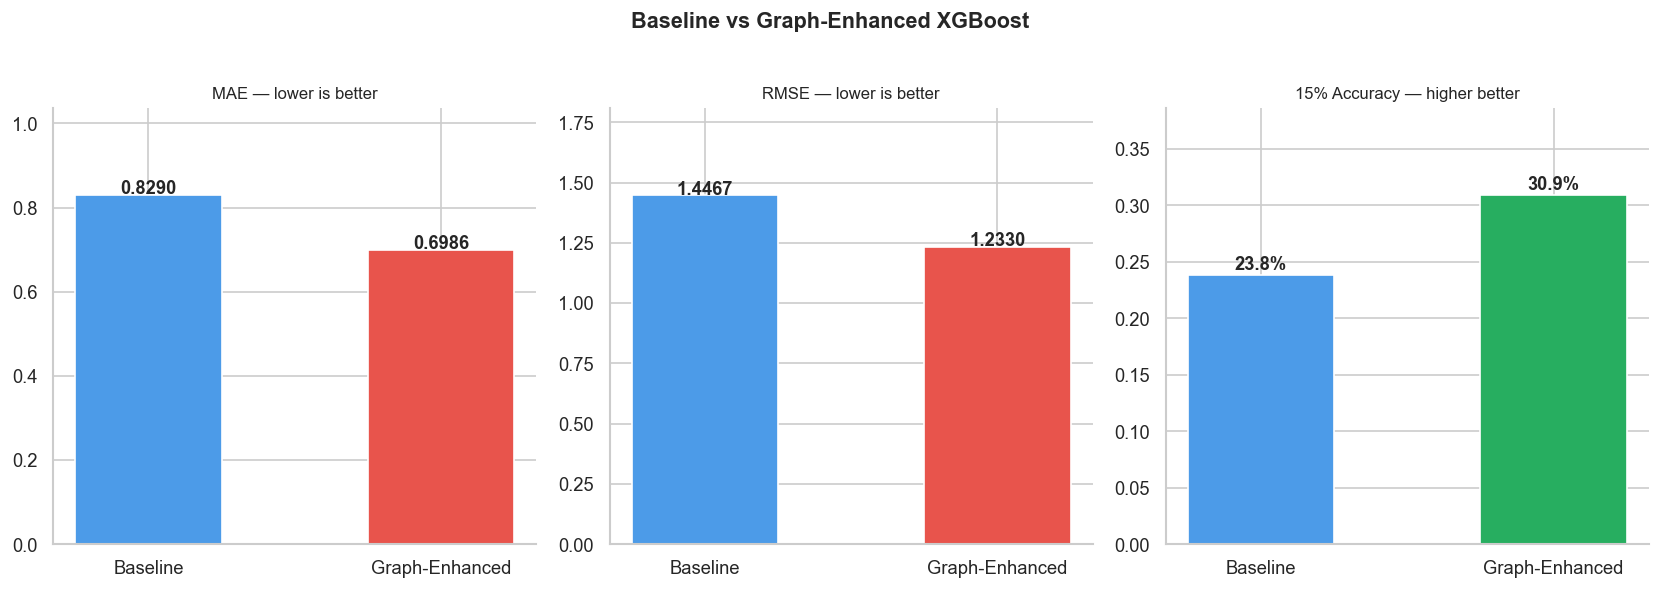

Saved 01_model_comparison.png


In [36]:
#step 6 is the visualisation and saving the visuals 
#model comparision bar chart 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
 
metrics_list = [
    ("MAE",           "MAE — lower is better",      [base_results["MAE"],          graph_results["MAE"]],          False),
    ("RMSE",          "RMSE — lower is better",      [base_results["RMSE"],         graph_results["RMSE"]],         False),
    ("15%_accuracy",  "15% Accuracy — higher better",[base_results["15%_accuracy"], graph_results["15%_accuracy"]], True),
]
 
for ax, (key, title, vals, higher_better) in zip(axes, metrics_list):
    colors = (
        ["#4C9BE8", "#27AE60"] if higher_better
        else ["#4C9BE8", "#E8544C"] if vals[1] < vals[0]
        else ["#4C9BE8", "#E87A4C"]
    )
    bars = ax.bar(["Baseline", "Graph-Enhanced"], vals, color=colors, width=0.5, edgecolor="white")
    for bar, val in zip(bars, vals):
        label = f"{val:.1%}" if key == "15%_accuracy" else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                label, ha="center", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.25)
 
fig.suptitle("Baseline vs Graph-Enhanced XGBoost\n", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 01_model_comparison.png")

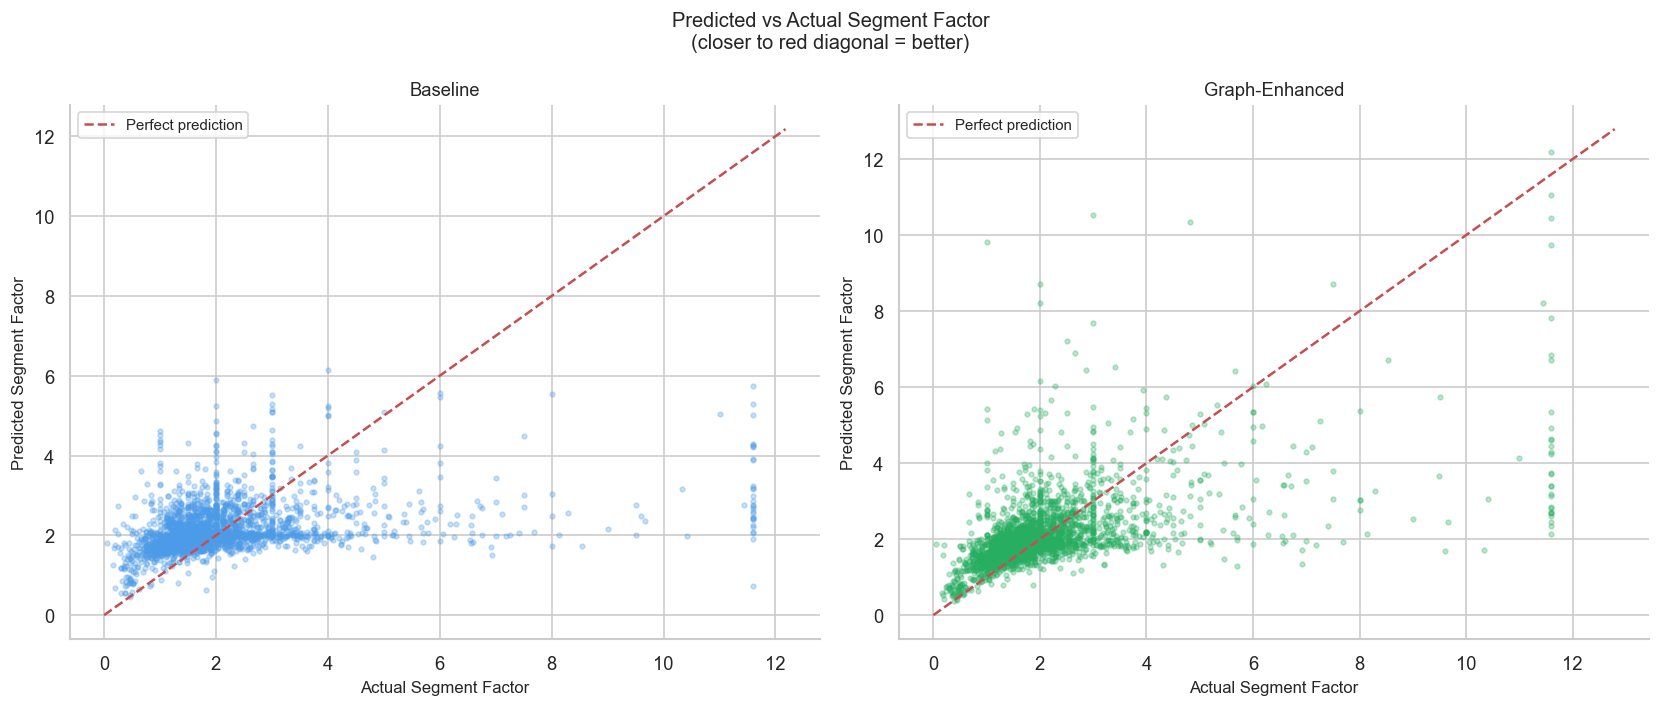

Saved 02_predicted_vs_actual.png


In [37]:
#predicted vs actual 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
y_sample   = y_test.values[sample_idx]
 
for ax, (preds, name, color) in zip(axes, [
    (base_results["predictions"][sample_idx],  "Baseline",       "#4C9BE8"),
    (graph_results["predictions"][sample_idx], "Graph-Enhanced", "#27AE60"),
]):
    ax.scatter(y_sample, preds, alpha=0.3, s=8, color=color)
    lim = max(y_sample.max(), preds.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Segment Factor", fontsize=10)
    ax.set_ylabel("Predicted Segment Factor", fontsize=10)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
 
fig.suptitle("Predicted vs Actual Segment Factor\n(closer to red diagonal = better)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 02_predicted_vs_actual.png")

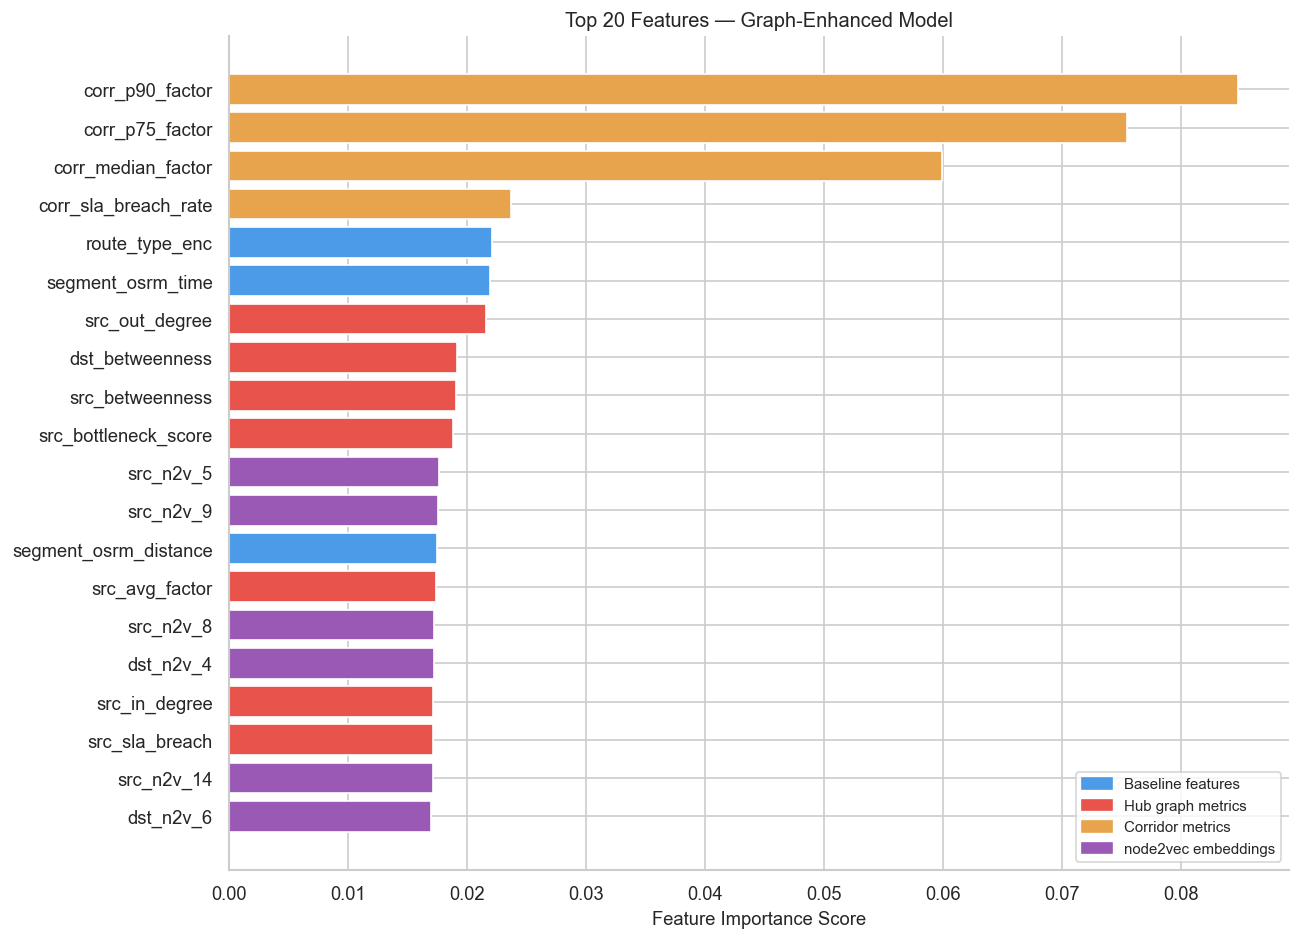

Saved 03_feature_importance.png


In [38]:
#feature importance 
feat_imp = pd.DataFrame({
    "feature"    : GRAPH_FEATURES,
    "importance" : enhanced_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)
 
# Color by feature type
def feature_color(f):
    if f.startswith(("src_n2v","dst_n2v")):
        return "#9B59B6"   # purple = node2vec
    elif f.startswith(("src_","dst_")):
        return "#E8544C"   # red = hub graph metrics
    elif f.startswith("corr_"):
        return "#E8A44C"   # orange = corridor metrics
    else:
        return "#4C9BE8"   # blue = baseline
 
colors_fi = [feature_color(f) for f in feat_imp["feature"]]
 
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1],
        color=colors_fi[::-1], edgecolor="white")
ax.set_xlabel("Feature Importance Score", fontsize=11)
ax.set_title("Top 20 Features — Graph-Enhanced Model", fontsize=12)
ax.spines[["top","right"]].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color="#4C9BE8", label="Baseline features"),
    mpatches.Patch(color="#E8544C", label="Hub graph metrics"),
    mpatches.Patch(color="#E8A44C", label="Corridor metrics"),
    mpatches.Patch(color="#9B59B6", label="node2vec embeddings"),
], fontsize=9)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 03_feature_importance.png")

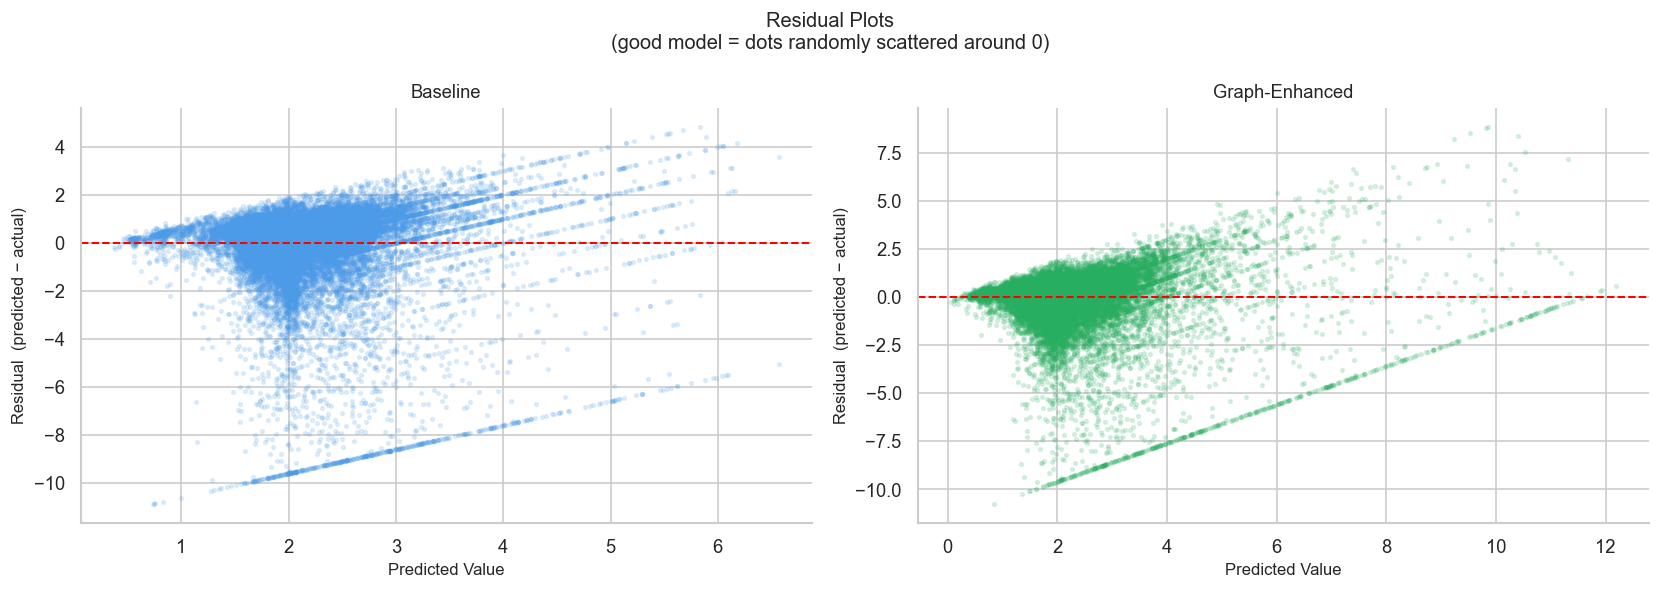

Saved 04_residuals.png


In [39]:
#residuals 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, (preds, name, color) in zip(axes, [
    (base_results["predictions"],  "Baseline",       "#4C9BE8"),
    (graph_results["predictions"], "Graph-Enhanced", "#27AE60"),
]):
    residuals = preds - y_test.values
    ax.scatter(preds, residuals, alpha=0.15, s=5, color=color)
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Predicted Value", fontsize=10)
    ax.set_ylabel("Residual  (predicted − actual)", fontsize=10)
    ax.set_title(f"{name}", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
 
fig.suptitle("Residual Plots\n(good model = dots randomly scattered around 0)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 04_residuals.png")
 

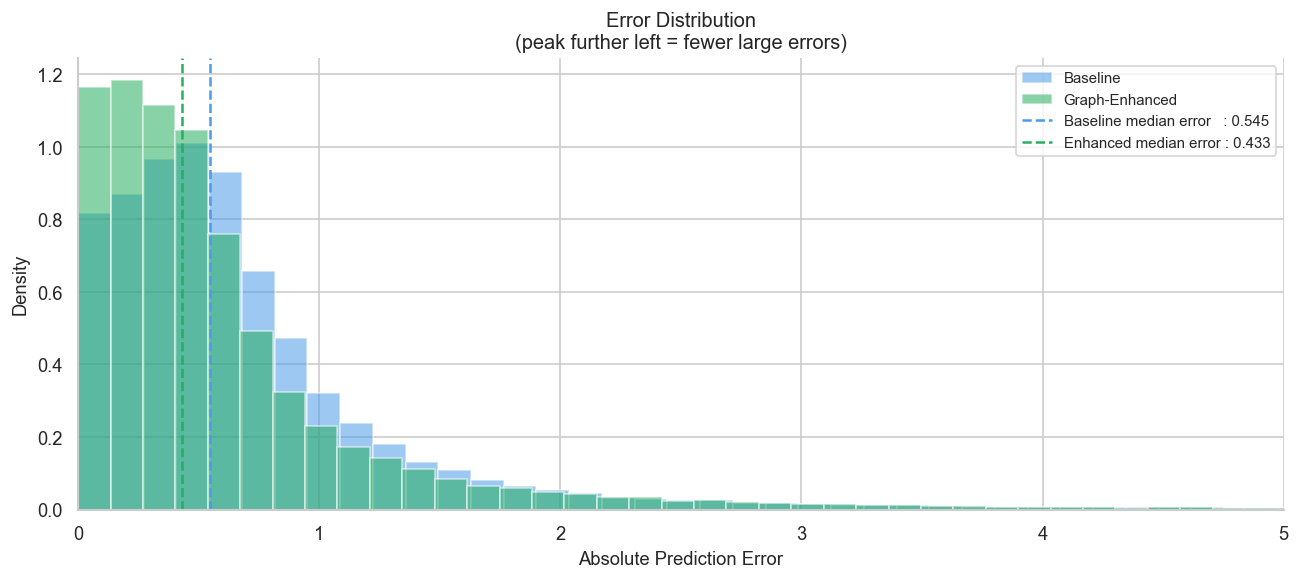

Saved 05_error_distribution.png


In [40]:
#error distribution
base_errors  = np.abs(base_results["predictions"]  - y_test.values)
graph_errors = np.abs(graph_results["predictions"] - y_test.values)
 
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(base_errors,  bins=80, alpha=0.55, color="#4C9BE8", label="Baseline",       density=True)
ax.hist(graph_errors, bins=80, alpha=0.55, color="#27AE60", label="Graph-Enhanced", density=True)
ax.axvline(x=np.median(base_errors),  color="#4C9BE8", linestyle="--", linewidth=1.5,
           label=f"Baseline median error   : {np.median(base_errors):.3f}")
ax.axvline(x=np.median(graph_errors), color="#27AE60", linestyle="--", linewidth=1.5,
           label=f"Enhanced median error : {np.median(graph_errors):.3f}")
ax.set_xlabel("Absolute Prediction Error", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Error Distribution\n(peak further left = fewer large errors)", fontsize=12)
ax.set_xlim(0, 5)
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 05_error_distribution.png")

In [41]:
baseline_model.save_model(f"{OUT_DIR}/baseline_model.json")
enhanced_model.save_model(f"{OUT_DIR}/enhanced_model.json")
 
print("Models saved")
print(f"  {OUT_DIR}/baseline_model.json")
print(f"  {OUT_DIR}/enhanced_model.json")
print()
print("To reload in Phase 4:")
print("  from xgboost import XGBRegressor")
print("  model = XGBRegressor()")
print("  model.load_model('../outputs/enhanced_model.json')")

Models saved
  ../data/processed/baseline_model.json
  ../data/processed/enhanced_model.json

To reload in Phase 4:
  from xgboost import XGBRegressor
  model = XGBRegressor()
  model.load_model('../outputs/enhanced_model.json')


In [42]:
print("=" * 60)
print("  PHASE 3 COMPLETE")
print("=" * 60)
print()
print("BENCHMARK:")
print(f"  Baseline  MAE     : {base_results['MAE']:.4f}")
print(f"  Enhanced  MAE     : {graph_results['MAE']:.4f}")
print(f"  MAE improvement   : {mae_imp:.1f}%")
print()
print(f"  Baseline  15% acc : {base_results['15%_accuracy']:.1%}")
print(f"  Enhanced  15% acc : {graph_results['15%_accuracy']:.1%}")
print(f"  Acc improvement   : +{acc_imp:.1f}%")
print()
print("FILES SAVED:")
files = [
    ("baseline_model.json",        "baseline XGBoost"),
    ("enhanced_model.json",        "graph-enhanced XGBoost"),
    ("node2vec_embeddings.csv",    "hub vectors — Phase 4 reuses this"),
    ("model_benchmark.csv",        "MAE, RMSE, 15% accuracy comparison"),
    ("test_predictions.csv",       "actual vs predicted per trip"),
    ("phase3_visuals/",            "5 charts"),
]
for fname, desc in files:
    print(f"  outputs/{fname:<35} ← {desc}")
print()
print("  → Phase 4: FTL vs Carting decision framework")


  PHASE 3 COMPLETE

BENCHMARK:
  Baseline  MAE     : 0.8290
  Enhanced  MAE     : 0.6986
  MAE improvement   : 15.7%

  Baseline  15% acc : 23.8%
  Enhanced  15% acc : 30.9%
  Acc improvement   : +29.5%

FILES SAVED:
  outputs/baseline_model.json                 ← baseline XGBoost
  outputs/enhanced_model.json                 ← graph-enhanced XGBoost
  outputs/node2vec_embeddings.csv             ← hub vectors — Phase 4 reuses this
  outputs/model_benchmark.csv                 ← MAE, RMSE, 15% accuracy comparison
  outputs/test_predictions.csv                ← actual vs predicted per trip
  outputs/phase3_visuals/                     ← 5 charts

  → Phase 4: FTL vs Carting decision framework
